   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


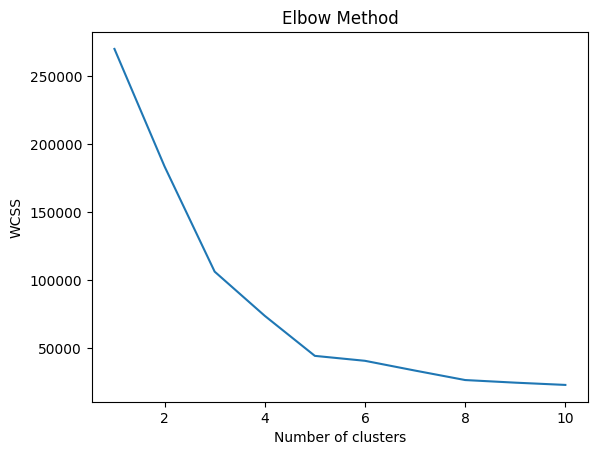

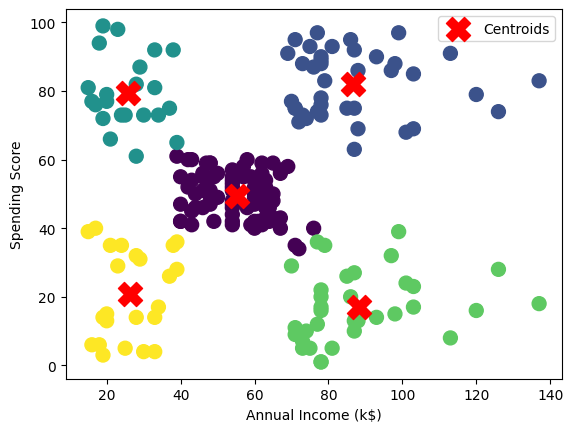


Analisis per Cluster:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [1]:
# Project Clustering Pertama: Segmentasi Customer Mall
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('Mall_Customers.csv')
print(df.head())

# 2. Pilih 2 fitur untuk visualisasi
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Cari optimal k dengan Elbow Method
wcss = []  # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Apply K-Means dengan k=5 (biasanya optimal untuk dataset ini)
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X)

# 5. Visualisasi hasil clustering
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['Cluster'], cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

# 6. Analisis cluster (versi eksplisit: hanya kolom numerik)
numeric_cols = ["Age", 'Annual Income (k$)', 'Spending Score (1-100)']
cluster_analysis = df.groupby('Cluster')[numeric_cols].mean()

print("\nAnalisis per Cluster:")
print(cluster_analysis)